<a href="https://colab.research.google.com/github/SudhanshuSekharNaik/Historical-Photo-Colorization-with-cnn/blob/main/colourizedipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
import os
from PIL import Image
import glob

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [4]:
class DataPreprocessor:
    def __init__(self, target_size=(256, 256)):
        self.target_size = target_size

    def load_and_preprocess_image(self, image_path):
        """Load and preprocess a single image"""
        try:
            # Read image
            image = tf.io.read_file(image_path)
            image = tf.image.decode_image(image, channels=3)
            image = tf.image.resize(image, self.target_size)
            image = tf.cast(image, tf.float32) / 255.0

            # Convert RGB to Lab color space
            lab_image = tf.py_function(self.rgb_to_lab, [image], tf.float32)
            lab_image.set_shape([*self.target_size, 3])

            return lab_image
        except:
            # Return zeros if image is corrupted
            return tf.zeros([*self.target_size, 3], dtype=tf.float32)

    def rgb_to_lab(self, rgb_image):
        """Convert RGB image to Lab color space using OpenCV"""
        rgb_image = rgb_image.numpy()
        lab_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2LAB)
        return lab_image.astype(np.float32)

    def prepare_dataset(self, image_paths, batch_size=32, shuffle=True):
        """Create TensorFlow dataset"""
        dataset = tf.data.Dataset.from_tensor_slices(image_paths)

        if shuffle:
            dataset = dataset.shuffle(buffer_size=len(image_paths))

        dataset = dataset.map(self.load_and_preprocess_image,
                            num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.batch(batch_size)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)

        return dataset

    def lab_to_rgb(self, lab_image):
        """Convert Lab image back to RGB"""
        if isinstance(lab_image, tf.Tensor):
            lab_image = lab_image.numpy()

        # Denormalize Lab values
        lab_image[:, :, 0] = lab_image[:, :, 0] * 100  # L channel [0,100]
        lab_image[:, :, 1:] = lab_image[:, :, 1:] * 255 - 128  # a,b channels [-128,127]

        lab_image = lab_image.astype(np.uint8)
        rgb_image = cv2.cvtColor(lab_image, cv2.COLOR_LAB2RGB)
        return rgb_image

In [5]:
def build_colorization_autoencoder(input_shape=(256, 256, 1)):
    """Build the CNN autoencoder for colorization"""

    # Input - L channel (grayscale)
    inputs = keras.Input(shape=input_shape, name='grayscale_input')

    # Encoder
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)  # 128x128

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)  # 64x64

    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)  # 32x32

    # Bottleneck
    x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Decoder
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)  # 64x64

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)  # 128x128

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)  # 256x256

    # Output - ab channels (color information)
    outputs = layers.Conv2D(2, (3, 3), activation='tanh', padding='same', name='color_output')(x)

    model = keras.Model(inputs, outputs, name='colorization_autoencoder')
    return model

# Build and display model
model = build_colorization_autoencoder()
model.summary()

Model: "colorization_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ grayscale_input (InputLayer)    │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 256)    │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,105,346 (11.85 MB)

 Trainable params: 3,102,530 (11.84 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [6]:
class ColorizationLoss:
    def __init__(self, alpha=0.5):
        self.alpha = alpha  # Weight for combined loss

    def mse_loss(self, y_true, y_pred):
        """Mean Squared Error loss"""
        return tf.reduce_mean(tf.square(y_true - y_pred))

    def perceptual_loss(self, y_true, y_pred):
        """Perceptual loss using VGG16 features"""
        # Load pre-trained VGG16
        vgg = tf.keras.applications.VGG16(include_top=False, weights='imagenet',
                                         input_shape=(256, 256, 3))
        vgg.trainable = False

        # Create feature extractor
        feature_extractor = keras.Model(inputs=vgg.input,
                                      outputs=vgg.get_layer('block3_conv3').output)

        # Convert Lab to RGB for VGG
        def lab_to_rgb_for_vgg(lab_batch):
            rgb_batch = []
            for lab in lab_batch:
                # Create fake L channel (50) and combine with ab
                fake_l = tf.ones_like(lab[..., :1]) * 50
                fake_lab = tf.concat([fake_l, lab], axis=-1)
                rgb = tf.py_function(DataPreprocessor().lab_to_rgb, [fake_lab], tf.float32)
                rgb_batch.append(rgb)
            return tf.stack(rgb_batch)

        true_rgb = lab_to_rgb_for_vgg(y_true)
        pred_rgb = lab_to_rgb_for_vgg(y_pred)

        # Extract features
        true_features = feature_extractor(true_rgb)
        pred_features = feature_extractor(pred_rgb)

        return tf.reduce_mean(tf.square(true_features - pred_features))

    def combined_loss(self, y_true, y_pred):
        """Combined MSE and perceptual loss"""
        mse = self.mse_loss(y_true, y_pred)
        perceptual = self.perceptual_loss(y_true, y_pred)
        return self.alpha * mse + (1 - self.alpha) * perceptual

# Custom metric for color accuracy
def color_accuracy(y_true, y_pred):
    """Simple color accuracy metric"""
    threshold = 0.1  # 10% error tolerance
    correct_pixels = tf.reduce_sum(tf.cast(tf.abs(y_true - y_pred) < threshold, tf.float32))
    total_pixels = tf.cast(tf.size(y_true), tf.float32)
    return correct_pixels / total_pixels

In [11]:
class ColorizationTrainer:
    def __init__(self, model, preprocessor):
        self.model = model
        self.preprocessor = preprocessor
        self.history = None

    def prepare_training_data(self, lab_images):
        """Prepare training data: L channel as input, ab channels as target"""
        X = []  # L channel
        y = []  # ab channels

        for lab_image in lab_images:
            # Check if image is corrupted (all zeros)
            if np.sum(lab_image) == 0:
                continue

            # Split Lab image (using numpy slicing)
            L_channel = lab_image[:, :, 0:1]  # Grayscale (0-1)
            ab_channels = lab_image[:, :, 1:3]  # Color channels (-1 to 1)

            # Normalize ab channels to [-1, 1]
            # Note: The DataPreprocessor already normalizes L channel to [0,1] and ab to [-128, 127] / 255.0
            # We need to normalize ab to [-1, 1] for tanh activation in the output layer.
            ab_channels = (ab_channels * 255 - 128) / 128.0 # Scale ab to roughly [-1, 1] based on typical Lab ranges

            X.append(L_channel)
            y.append(ab_channels)

        return np.array(X), np.array(y)

    def train(self, image_paths, epochs=50, batch_size=16, validation_split=0.2):
        """Train the colorization model"""

        # Load and preprocess images
        print("Loading and preprocessing images...")
        # Load all images first without batching for easier split
        dataset = self.preprocessor.prepare_dataset(image_paths, batch_size=len(image_paths), shuffle=False)
        # Unbatch and convert to numpy for splitting
        lab_images = list(dataset.unbatch().as_numpy_iterator())

        # Prepare training data
        X, y = self.prepare_training_data(lab_images)
        print(f"Training data shape: {X.shape}, Targets shape: {y.shape}")

        # Check if there is enough data after filtering corrupted images
        if len(X) == 0:
            print("No valid images found for training.")
            return None

        # Split data
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=validation_split, random_state=42
        )

        # Compile model
        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss=ColorizationLoss().combined_loss,
            metrics=[color_accuracy]
        )

        # Callbacks
        callbacks = [
            keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
            keras.callbacks.ModelCheckpoint(
                'best_colorization_model.h5',
                save_best_only=True,
                monitor='val_loss'
            )
        ]

        # Train model
        print("Starting training...")
        self.history = self.model.fit(
            X_train, y_train,
            batch_size=batch_size,
            epochs=epochs,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            verbose=1
        )

        return self.history

    def plot_training_history(self):
        """Plot training history"""
        if self.history is None:
            print("No training history available.")
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # Plot loss
        ax1.plot(self.history.history['loss'], label='Training Loss')
        ax1.plot(self.history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()

        # Plot accuracy
        ax2.plot(self.history.history['color_accuracy'], label='Training Accuracy')
        ax2.plot(self.history.history['val_color_accuracy'], label='Validation Accuracy')
        ax2.set_title('Color Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()

        plt.tight_layout()
        plt.show()

In [8]:
class ColorizationInference:
    def __init__(self, model_path=None):
        if model_path and os.path.exists(model_path):
            self.model = keras.models.load_model(model_path,
                                               custom_objects={
                                                   'combined_loss': ColorizationLoss().combined_loss,
                                                   'color_accuracy': color_accuracy
                                               })
        else:
            self.model = build_colorization_autoencoder()
        self.preprocessor = DataPreprocessor()

    def colorize_image(self, grayscale_image):
        """Colorize a grayscale image"""
        if isinstance(grayscale_image, str):
            # Load image from file
            grayscale_image = self.preprocessor.load_and_preprocess_image(grayscale_image)
            grayscale_image = grayscale_image.numpy()

        # Extract L channel
        if grayscale_image.shape[-1] == 3:  # If it's Lab format
            L_channel = grayscale_image[:, :, 0:1]
        else:  # If it's grayscale
            L_channel = np.expand_dims(grayscale_image, axis=-1)

        # Predict ab channels
        ab_channels = self.model.predict(np.expand_dims(L_channel, axis=0))[0]

        # Denormalize ab channels
        ab_channels = (ab_channels + 1) / 2

        # Combine L and predicted ab
        L_normalized = L_channel  # Already in [0,1]
        colorized_lab = np.concatenate([L_normalized, ab_channels], axis=-1)

        return colorized_lab

    def display_results(self, original_path, save_path=None):
        """Display original grayscale and colorized result"""
        # Load and process image
        lab_image = self.preprocessor.load_and_preprocess_image(original_path).numpy()
        L_channel = lab_image[:, :, 0:1]

        # Colorize
        colorized_lab = self.colorize_image(lab_image)

        # Convert to RGB for display
        original_rgb = self.preprocessor.lab_to_rgb(
            np.concatenate([L_channel, np.zeros_like(L_channel), np.zeros_like(L_channel)], axis=-1)
        )
        colorized_rgb = self.preprocessor.lab_to_rgb(colorized_lab)

        # Plot results
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        axes[0].imshow(original_rgb)
        axes[0].set_title('Original Grayscale')
        axes[0].axis('off')

        axes[1].imshow(colorized_rgb)
        axes[1].set_title('Colorized')
        axes[1].axis('off')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()

        return colorized_rgb

Preparing training data...
Loading and preprocessing images...


Training data shape: (0,), Targets shape: (0,)
No valid images found for training.
No training history available.
Model saved to historical_colorization_model.h5


Colorizing temp_image_0.jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step


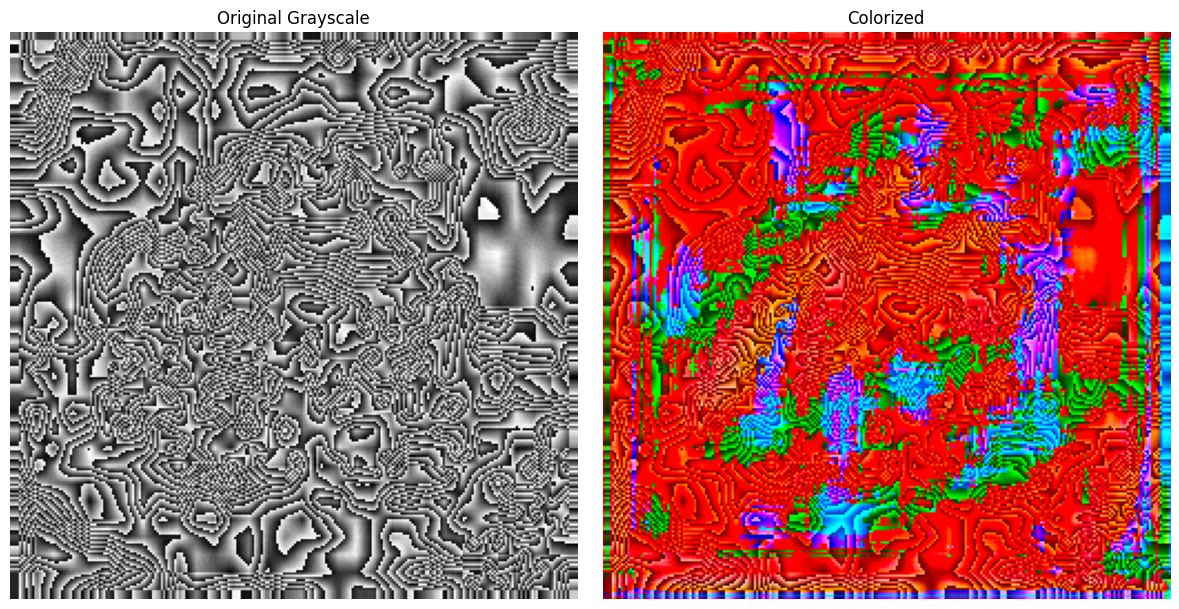

Colorizing temp_image_1.jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step


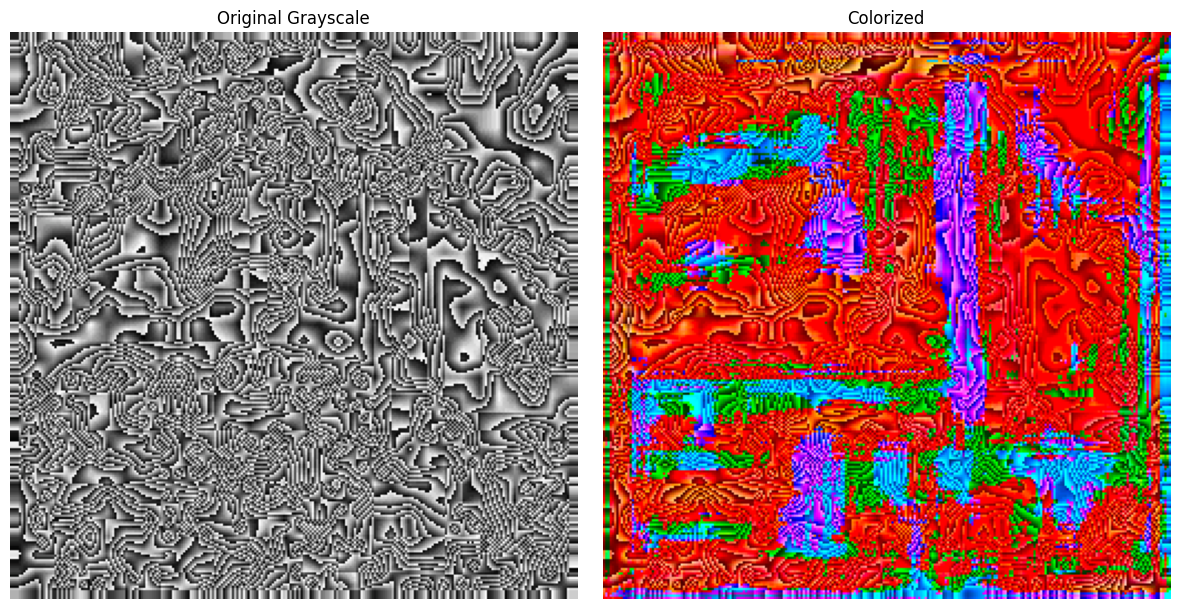

Colorizing temp_image_2.jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step


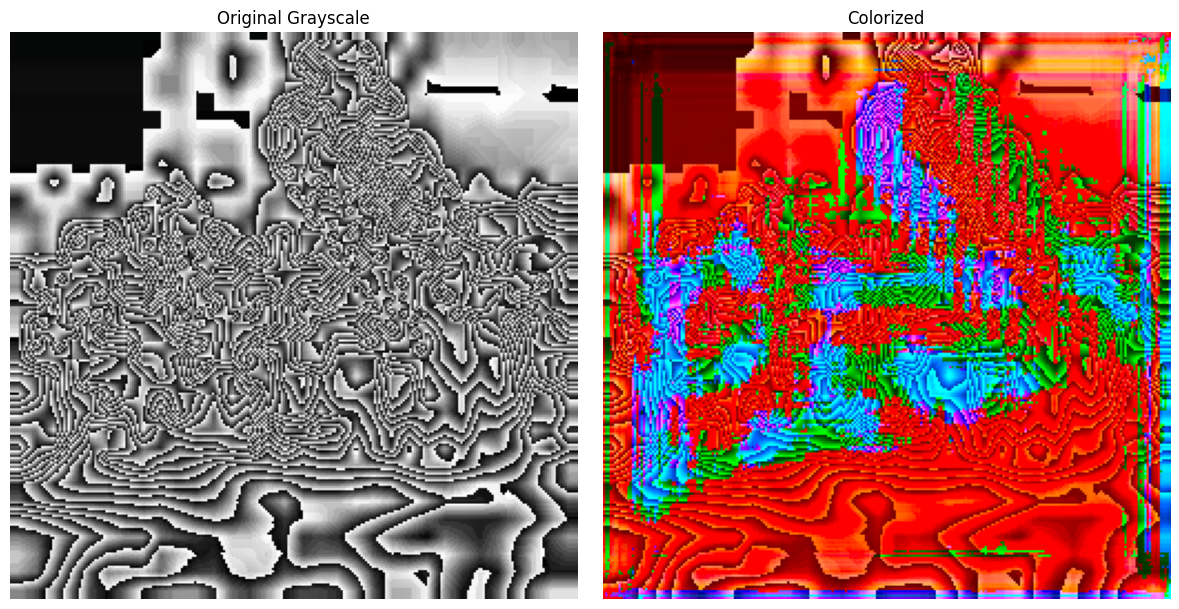

In [12]:
def main():
    # Configuration
    DATA_DIR = "path/to/your/images"  # Change this to your image directory
    MODEL_SAVE_PATH = "historical_colorization_model.h5"

    # Get image paths (you can use any dataset - COCO, ImageNet, etc.)
    # For demo purposes, let's create a function to find images
    def get_sample_images():
        """Get sample images for training"""
        # You can download sample datasets or use your own
        # For quick testing, you can use tf.keras.datasets.cifar10
        (x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

        # Convert to file paths (simulated)
        image_paths = []
        for i in range(min(1000, len(x_train))):  # Use first 1000 images
            # Save temporary images
            img = Image.fromarray(x_train[i])
            path = f"temp_image_{i}.jpg"
            img.save(path)
            image_paths.append(path)

        return image_paths

    # Initialize components
    preprocessor = DataPreprocessor(target_size=(256, 256))
    model = build_colorization_autoencoder()

    # Get training data
    print("Preparing training data...")
    image_paths = get_sample_images()

    # Train model
    trainer = ColorizationTrainer(model, preprocessor)
    history = trainer.train(image_paths, epochs=30, batch_size=8)

    # Plot training history
    trainer.plot_training_history()

    # Save model
    model.save(MODEL_SAVE_PATH)
    print(f"Model saved to {MODEL_SAVE_PATH}")

    # Test inference
    inference = ColorizationInference(MODEL_SAVE_PATH)

    # Test on a few images
    test_images = image_paths[:3]  # Use first 3 images for testing
    for img_path in test_images:
        print(f"Colorizing {img_path}...")
        inference.display_results(img_path)

    # Clean up temporary files
    for path in image_paths:
        if os.path.exists(path):
            os.remove(path)

if __name__ == "__main__":
    main()

In [ ]:
if __name__ == "__main__":
    # Set random seeds for reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)

    # Run demonstration
    main()

In [13]:
# Quick test with minimal setup
def quick_demo():
    """Quick demo with synthetic data"""
    # Create a simple model
    model = build_colorization_autoencoder(input_shape=(128, 128, 1))

    # Generate synthetic data
    X_train = np.random.random((100, 128, 128, 1))  # Random grayscale images
    y_train = np.random.random((100, 128, 128, 2)) * 2 - 1  # Random color channels

    # Test prediction
    test_image = np.random.random((1, 128, 128, 1))
    prediction = model.predict(test_image)
    print("Prediction shape:", prediction.shape)
    print("Demo completed successfully!")

# Run quick demo
quick_demo()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step
Prediction shape: (1, 128, 128, 2)
Demo completed successfully!
